# RollingLDA sobre bpoil

Modelo de tópicos dinámico que ajusta `scripts/fit_rolling_lda.py` sobre el
subset bpoil (derrame de Deepwater Horizon, corpus NEWS-TLS T17), recortado a
abril-septiembre de 2010. Este notebook carga el modelo guardado en
`data/roll_lda_bpoil.pickle` y no lo reajusta. Si el archivo no existe, hay que
correr antes ese script (tarda unos 20 minutos).

RollingLDA divide el corpus en ventanas de tiempo (chunks). Los primeros
`warmup` chunks se ajustan juntos como un LDA normal. Cada chunk siguiente se
ajusta usando como prior los `memory` chunks anteriores, así un tópico conserva
su identidad de un chunk al siguiente en vez de reordenarse. Paper y paquete en
las [referencias del README](../README.md#rollinglda).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from causal_coherence.config import PROJECT_ROOT
from causal_coherence.topic_model import (
    LDA_CONFIG,
    MODEL_PATH,
    chunk_summary,
    load_topic_model,
    training_documents,
)

pd.set_option("display.max_colwidth", None)
plt.rcParams["figure.dpi"] = 90

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"No existe {MODEL_PATH.relative_to(PROJECT_ROOT)}; correr antes python scripts/fit_rolling_lda.py"
    )

roll = load_topic_model()
docs = training_documents()
print(f"Modelo: {MODEL_PATH.relative_to(PROJECT_ROOT).as_posix()}")
print(f"K = {LDA_CONFIG['K']} tópicos · warmup = {LDA_CONFIG['warmup']} · memory = {LDA_CONFIG['memory']}")
print(f"{len(docs)} documentos, de {docs['date'].min().date()} a {docs['date'].max().date()}")

Modelo: data/roll_lda_bpoil.pickle
K = 10 tópicos · warmup = 2 · memory = 3
1011 documentos, de 2010-04-01 a 2010-09-30


## Chunks

Los cortes vienen de `CUSTOM_CHUNKS` en `src/causal_coherence/topic_model.py`,
donde también está la justificación del truncamiento a septiembre. Cada fecha de
corte es el primer día de un chunk y los cortes están puestos el último día de
cada mes; por eso el chunk 1 va del 31 de mayo al 29 de junio. El chunk 0 junta
abril y mayo porque `warmup = 2`.

In [2]:
chunk_summary(roll, docs)

,documentos,desde,hasta
chunk,,,
0,303,2010-04-01,2010-05-30
1,338,2010-05-31,2010-06-29
2,214,2010-06-30,2010-07-30
3,82,2010-07-31,2010-08-26
4,74,2010-09-02,2010-09-30


## Palabras principales por tópico

`top_words` usa `importance=True`, el valor por defecto de ttta: en vez de
ordenar por frecuencia bruta, baja el peso de las palabras que se reparten entre
muchos tópicos. Las palabras son lemas en minúscula, como quedan después de
`preprocessing.py`. Estas son las palabras del modelo completo, sumando todos
los chunks.

In [3]:
top = roll.top_words(number=10, return_as_data_frame=False)
pd.DataFrame({"palabras": [", ".join(words) for words in top]}).rename_axis("tópico")

,palabras
tópico,
0,"obama, president, house, administration, white, government, energy, drilling, coast, response"
1,"oil, coast, mile, louisiana, slick, dispersant, storm, water, say, surface"
2,"reuters, percent, comment, billion, trading, generation, ultra, welcome, data, connected"
3,"bp, hayward, mr, share, company, dividend, british, tony, chief, executive"
4,"bp, claim, billion, pay, cost, fund, feinberg, compensation, law, company"
5,"know, think, thing, right, pm, bp, like, post, go, want"
6,"beach, fish, bird, boat, louisiana, fishing, wildlife, shrimp, fisherman, marsh"
7,"world, industry, gas, oil, change, energy, disaster, green, science, climate"
8,"leak, cap, pipe, bp, flow, surface, mud, allen, pressure, oil"


### El mismo tópico en cada chunk

Cada chunk tiene su propia matriz palabra-tópico. El tópico 8 (contención del
pozo) sirve de ejemplo para ver cómo cambia su vocabulario a medida que avanza
el derrame, sin dejar de ser el mismo tópico.

In [4]:
TOPIC = 8
pd.DataFrame({
    f"chunk {c}": roll.top_words(chunk=c, topic=TOPIC, number=8, return_as_data_frame=False)
    for c in range(len(roll.chunk_indices))
})

,chunk 0,chunk 1,chunk 2,chunk 3,chunk 4
0,leak,leak,cap,mud,leak
1,pipe,pipe,leak,static,flow
2,bp,cap,test,leak,cement
3,mud,flow,allen,pump,pipe
4,surface,surface,pressure,kill,pressure
5,pump,bp,flow,allen,cap
6,flow,estimate,bp,relief,seal
7,preventer,riser,oil,cap,preventer


## Matriz documento-tópico (theta)

`get_document_topic_matrix()` devuelve, para cada documento, cuántos de sus
tokens quedaron asignados a cada tópico. `topic_shares(chunk=None)` (también de
ttta) normaliza cada fila para que sume 1: esa es la proporción de tópicos del
documento, theta.

El modelo guardado no incluye las fechas. Las filas siguen el orden en que
`RollingLDA.fit` procesa los documentos (ordenados por fecha, con orden
estable), y `training_documents()` reconstruye ese mismo orden. La celda
comprueba que coincidan el número de filas y las fechas de los bordes de chunk.

In [5]:
counts = roll.get_document_topic_matrix()
theta = roll.topic_shares(chunk=None)  # por defecto (chunk="all") devuelve el promedio por chunk
theta.columns = range(theta.shape[1])
theta.index = docs.index

# Comprobación de alineación: cada chunk (salvo el primero) debe empezar en el
# primer documento con fecha >= la fecha de corte que guarda el modelo.
starts = roll.chunk_indices["chunk_start"].iloc[1:]
cuts = roll.chunk_indices["date"].iloc[1:].values
assert len(theta) == len(docs)
assert (docs["date"].iloc[starts].values >= cuts).all()
assert (docs["date"].iloc[starts - 1].values < cuts).all()
chunk_dates = docs["date"].iloc[starts]

tokens = counts.sum(axis=1)
print("forma de theta:", theta.shape, "(documentos x tópicos)")
print(f"tokens por documento: mediana {np.median(tokens):.0f}, mínimo {tokens.min()}, máximo {tokens.max()}")
print("documentos sin tokens:", int((tokens == 0).sum()))
print("filas que suman 1:", bool(np.allclose(theta[tokens > 0].sum(axis=1), 1)))
print(f"proporción del tópico dominante por documento: mediana {theta.max(axis=1).median():.2f}")

forma de theta: (1011, 10) (documentos x tópicos)
tokens por documento: mediana 335, mínimo 8, máximo 4846
documentos sin tokens: 0
filas que suman 1: True
proporción del tópico dominante por documento: mediana 0.49


Cinco documentos repartidos en el período, con su proporción de cada tópico:

In [6]:
sample = theta.iloc[[0, 250, 500, 750, 1000]].round(2)
sample.insert(0, "fecha", docs.loc[sample.index, "date"].dt.date)
sample

,fecha,0,1,2,3,4,5,6,7,8,9
0,2010-04-01,0.57,0.00,0.00,0.00,0.02,0.00,0.00,0.19,0.00,0.22
250,2010-05-27,0.30,0.21,0.00,0.01,0.00,0.00,0.01,0.00,0.35,0.13
500,2010-06-15,0.56,0.00,0.00,0.00,0.04,0.00,0.00,0.37,0.01,0.02
750,2010-07-16,0.03,0.18,0.01,0.00,0.08,0.49,0.14,0.00,0.00,0.07
1000,2010-09-28,0.36,0.02,0.08,0.03,0.49,0.00,0.00,0.01,0.00,0.00


## Prevalencia de tres tópicos en el tiempo

Tres tópicos elegidos por su vocabulario (tabla de palabras de arriba): 8,
contención del pozo; 4, compensaciones y reclamos; 6, impacto en costas y fauna.

La prevalencia semanal de un tópico es la suma de tokens asignados a ese tópico
en la semana dividida por el total de tokens de la semana. Es el mismo criterio
que usa `topic_shares(average=True)` de ttta para un chunk completo. Las líneas
punteadas marcan los bordes de chunk. El panel de abajo muestra cuántos
documentos hay cada semana; las semanas con pocos documentos son más ruidosas.

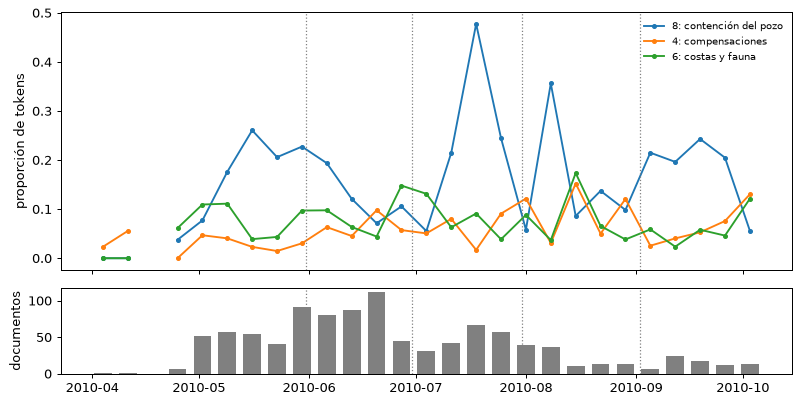

In [7]:
TOPICS = {8: "contención del pozo", 4: "compensaciones", 6: "costas y fauna"}

weekly_counts = pd.DataFrame(counts, index=docs["date"]).resample("W").sum()
weekly_share = weekly_counts.div(weekly_counts.sum(axis=1).replace(0, np.nan), axis=0)
docs_per_week = docs.set_index("date").resample("W").size()

fig, (ax, ax_n) = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True, height_ratios=[3, 1])
for k, label in TOPICS.items():
    ax.plot(weekly_share.index, weekly_share[k], marker="o", ms=3, lw=1.5, label=f"{k}: {label}")
for d in chunk_dates:
    ax.axvline(d, color="grey", ls=":", lw=1)
    ax_n.axvline(d, color="grey", ls=":", lw=1)
ax.set_ylabel("proporción de tokens")
ax.legend(frameon=False, fontsize=8, loc="upper right")
ax_n.bar(docs_per_week.index, docs_per_week.values, width=5, color="grey")
ax_n.set_ylabel("documentos")
fig.tight_layout()
plt.show()

Promedio por chunk de los mismos tres tópicos, calculado directamente con
`topic_shares(chunk="all")`:

In [8]:
by_chunk = roll.topic_shares(chunk="all")
by_chunk.columns = range(by_chunk.shape[1])
by_chunk[list(TOPICS)].rename(columns=TOPICS).rename_axis("chunk").round(3)

,contención del pozo,compensaciones,costas y fauna
chunk,,,
0,0.191,0.031,0.083
1,0.117,0.067,0.076
2,0.269,0.070,0.075
3,0.236,0.067,0.067
4,0.190,0.061,0.054


## Qué muestra el gráfico

La contención del pozo (tópico 8) alcanza su mayor prevalencia en la semana que
termina el 18 de julio (0,48) y tiene otro pico en la que termina el 8 de agosto
(0,36), además de una meseta de 0,2 a 0,26 entre mediados de mayo y comienzos
de junio. Esas semanas coinciden con los momentos de la contención que más
cubrió la prensa: la tapa que cortó el flujo el 15 de julio, el "static kill"
de comienzos de agosto y los intentos de mayo. El vocabulario del tópico por
chunk sigue la misma secuencia: *cap*, *test* y *pressure* en julio; *mud*,
*static*, *kill* y *relief* en agosto; *cement* y *seal* en septiembre.

Las compensaciones (tópico 4) pasan de 0,03 en el chunk 0 a cerca de 0,07 desde
junio y se mantienen en ese nivel. Costas y fauna (tópico 6) se mueve entre 0,02
y 0,17 por semana, con una baja leve por chunk (de 0,083 a 0,054). Las dos
primeras semanas de abril tienen un documento cada una, y desde mediados de
agosto hay entre 7 y 24 documentos por semana, así que los valores de esos
tramos son más inestables.